## Objectives
The objectives of this lab are:
1. To explore and apply **data acquisition techniques** for structured and unstructured datasets using Python.
2. To understand and compute **descriptive statistics** such as mean, median, mode, variance, standard deviation, and more.
3. To visualize key statistical measures like skewness and kurtosis using Python plotting libraries.
4. To clean and preprocess data effectively for accurate analysis.
5. To develop proficiency in working with APIs for social media and web data extraction.


### Fetching and Displaying Tables from Wikipedia

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from unicodedata import normalize

# Fetch all tables from the Minnesota Wikipedia page
table_MN = pd.read_html('https://en.wikipedia.org/wiki/Minnesota')

# Display all the fetched tables
table_MN

[                                            Minnesota  \
 0                                               State   
 1                                            FlagSeal   
 2   Nicknames: North Star State; Gopher State; Lan...   
 3   Motto: L'Étoile du Nord (French: The Star of t...   
 4                           Anthem: "Hail! Minnesota"   
 5   Map of the United States with Minnesota highli...   
 6                                             Country   
 7                                    Before statehood   
 8                               Admitted to the Union   
 9                                             Capital   
 10                                       Largest city   
 11                       Largest county or equivalent   
 12                      Largest metro and urban areas   
 13                                         Government   
 14                                         • Governor   
 15                              • Lieutenant governor   
 16           

In [2]:
# Print the total number of tables found on the page
print(f'Total tables: {len(table_MN)}')

Total tables: 29


### Selecting a Specific Table by Match

In [3]:
# Fetch tables matching the specific caption
table_MN = pd.read_html('https://en.wikipedia.org/wiki/Minnesota', match='United States presidential election results for Minnesota')
len(table_MN)

1

In [4]:
# Extract the first table from the results
df = table_MN[0]

# Display the structure of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   (Year, Year)             41 non-null     int64 
 1   (Republican, No.)        41 non-null     int64 
 2   (Republican, %)          41 non-null     object
 3   (Democratic, No.)        41 non-null     int64 
 4   (Democratic, %)          41 non-null     object
 5   (Third party(ies), No.)  41 non-null     int64 
 6   (Third party(ies), %)    41 non-null     object
dtypes: int64(4), object(3)
memory usage: 2.4+ KB


In [5]:
# Attempt to convert column to float (error expected)
df['Republican'].astype('float')

ValueError: could not convert string to float: '45.28%'

In [6]:
# get rid of % to convert Republican keys to float
df['Republican'].replace({'%': ''}, regex = True).astype('float')

,No.,%
0,1484065.0,45.28
1,1323232.0,44.93
2,1320225.0,44.96
3,1275409.0,43.82
4,1346695.0,47.61
5,1109659.0,45.50
6,766476.0,34.96
7,747841.0,31.85
8,962337.0,45.90
9,1032603.0,49.54


In [7]:
# Clean percentage signs and convert to numeric values
df['Republican'] = df['Republican'].replace({'%': ''}, regex=True).astype('float')
df['Democratic'] = df['Democratic'].replace({'%': ''}, regex=True).astype('float')
df['Third party(ies)'] = df['Third party(ies)'].replace({'%': ''}, regex=True).astype('float')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   (Year, Year)             41 non-null     int64  
 1   (Republican, No.)        41 non-null     float64
 2   (Republican, %)          41 non-null     float64
 3   (Democratic, No.)        41 non-null     float64
 4   (Democratic, %)          41 non-null     float64
 5   (Third party(ies), No.)  41 non-null     float64
 6   (Third party(ies), %)    41 non-null     float64
dtypes: float64(6), int64(1)
memory usage: 2.4 KB


Year Republican        Democratic        Third party(ies)      
   Year        No.      %        No.      %              No.     %
0  2020  1484065.0  45.28  1717077.0  52.40          76029.0  2.32
1  2016  1323232.0  44.93  1367825.0  46.44         254176.0  8.63
2  2012  1320225.0  44.96  1546167.0  52.65          70169.0  2.39
3  2008  1275409.0  43.82  1573354.0  54.06          61606.0  2.12
4  2004  1346695.0  47.61  1445014.0  51.09          36678.0  1.30

### Parsing GDP Data from Wikipedia

In [8]:
# Fetch and display GDP table from the Economy of the United States Wikipedia page
table_GDP = pd.read_html('https://en.wikipedia.org/wiki/Economy_of_the_United_States')
# Matching the index of the desired table instead
df_GDP = table_GDP[3]
df_GDP.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Year                             50 non-null     int64  
 1   GDP (in Bil. US$PPP)             50 non-null     float64
 2   GDP per capita (in US$ PPP)      50 non-null     float64
 3   GDP (in Bil. US$nominal)         50 non-null     float64
 4   GDP per capita (in US$ nominal)  50 non-null     float64
 5   GDP growth (real)                50 non-null     object 
 6   Inflation rate (in Percent)      50 non-null     object 
 7   Unemployment (in Percent)        50 non-null     object 
 8   Government debt (in % of GDP)    29 non-null     object 
dtypes: float64(4), int64(1), object(4)
memory usage: 3.6+ KB


### Cleaning and Normalizing DataFrame Values

In [10]:
# Attempt to clean GDP growth percentage values
df_GDP['GDP growth (real)'].replace({'%': ''}, regex=True).astype('float')

0    -0.3
1     2.5
2    -1.8
3     4.6
4     7.2
5     4.2
6     3.5
7     3.5
8     4.2
9     3.7
10    1.9
11   -0.1
12    3.5
13    2.8
14    4.0
15    2.7
16    3.8
17    4.4
18    4.5
19    4.8
20    4.1
21    1.0
22    1.7
23    2.8
24    3.9
25    3.5
26    2.8
27    2.0
28    0.1
29   -2.6
30    2.7
31    1.6
32    2.3
33    2.1
34    2.5
35    2.9
36    1.8
37    2.5
38    3.0
39    2.6
40   -2.2
41    6.1
42    2.5
43    2.9
44    2.8
45    2.2
46    2.0
47    2.1
48    2.1
49    2.1
Name: GDP growth (real), dtype: float64

In [11]:
# Import necessary library
from unicodedata import normalize

# Function to clean and normalize whitespace
def clean_normalize_whitespace(x):
    if isinstance(x, str):
        return normalize('NFKC', x).strip()
    else:
        return x

In [12]:
# Apply the cleaning function to the entire DataFrame
df_GDP = df_GDP.applymap(clean_normalize_whitespace)

/var/folders/qc/ylrp4vq57n590bhgm999r9fw0000gn/T/ipykernel_41029/2802173957.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_GDP = df_GDP.applymap(clean_normalize_whitespace)


In [13]:
# Check cleaned column names
df_GDP.columns[7]

'Unemployment (in Percent)'

In [14]:
# Clean column names using the cleaning function
df_GDP.columns = df_GDP.columns.to_series().apply(clean_normalize_whitespace)
# Check cleaned column names
df_GDP.columns[7]

'Unemployment (in Percent)'

In [15]:
# Attempt to clean percentage values and convert to float
df_GDP['GDP growth (real)'].replace({'%': ''}, regex=True).astype('float')

0    -0.3
1     2.5
2    -1.8
3     4.6
4     7.2
5     4.2
6     3.5
7     3.5
8     4.2
9     3.7
10    1.9
11   -0.1
12    3.5
13    2.8
14    4.0
15    2.7
16    3.8
17    4.4
18    4.5
19    4.8
20    4.1
21    1.0
22    1.7
23    2.8
24    3.9
25    3.5
26    2.8
27    2.0
28    0.1
29   -2.6
30    2.7
31    1.6
32    2.3
33    2.1
34    2.5
35    2.9
36    1.8
37    2.5
38    3.0
39    2.6
40   -2.2
41    6.1
42    2.5
43    2.9
44    2.8
45    2.2
46    2.0
47    2.1
48    2.1
49    2.1
Name: GDP growth (real), dtype: float64

In [16]:
# Remove hidden characters and convert values to float
df_GDP['GDP growth (real)'].replace({'%': '', '-': '-'}, regex=True).astype('float')

0    -0.3
1     2.5
2    -1.8
3     4.6
4     7.2
5     4.2
6     3.5
7     3.5
8     4.2
9     3.7
10    1.9
11   -0.1
12    3.5
13    2.8
14    4.0
15    2.7
16    3.8
17    4.4
18    4.5
19    4.8
20    4.1
21    1.0
22    1.7
23    2.8
24    3.9
25    3.5
26    2.8
27    2.0
28    0.1
29   -2.6
30    2.7
31    1.6
32    2.3
33    2.1
34    2.5
35    2.9
36    1.8
37    2.5
38    3.0
39    2.6
40   -2.2
41    6.1
42    2.5
43    2.9
44    2.8
45    2.2
46    2.0
47    2.1
48    2.1
49    2.1
Name: GDP growth (real), dtype: float64

In [17]:
# Clean the Year column and convert to integer
df['Year'].replace({'%': '', '-': '-', '\(est\)': ''}, regex=True).astype('int')

,Year
0,2020
1,2016
2,2012
3,2008
4,2004
5,2000
6,1996
7,1992
8,1988
9,1984


### Finalizing Data Cleaning and Type Conversion

In [18]:
# Define a dictionary for column data types
col_type = {'Year': 'float',
 'GDP (in Bil. US$PPP)': 'float',
 'GDP per capita (in US$ PPP)': 'float',
 'GDP (in Bil. US$nominal)': 'float',
 'GDP per capita (in US$ nominal)': 'float',
 'GDP growth (real)': 'float',
 'Inflation rate (in Percent)': 'float',
 'Unemployment (in Percent)': 'float',
 'Government debt (in % of GDP)': 'float'
}

In [19]:
# Generate a dictionary with float as the default type for all columns
dict.fromkeys(df_GDP.columns, 'float')

{'Year': 'float',
 'GDP (in Bil. US$PPP)': 'float',
 'GDP per capita (in US$ PPP)': 'float',
 'GDP (in Bil. US$nominal)': 'float',
 'GDP per capita (in US$ nominal)': 'float',
 'GDP growth (real)': 'float',
 'Inflation rate (in Percent)': 'float',
 'Unemployment (in Percent)': 'float',
 'Government debt (in % of GDP)': 'float'}

In [20]:
# Create a dictionary for cleaning values in the DataFrame
clean_dict = {'%': '', '-': '-', '\(est\)': ''}

In [21]:
# Clean and convert DataFrame values
df_GDP = df_GDP.replace(clean_dict, regex=True).replace({
    '-n/a ': np.nan
}).astype(col_type)
df_GDP.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Year                             50 non-null     float64
 1   GDP (in Bil. US$PPP)             50 non-null     float64
 2   GDP per capita (in US$ PPP)      50 non-null     float64
 3   GDP (in Bil. US$nominal)         50 non-null     float64
 4   GDP per capita (in US$ nominal)  50 non-null     float64
 5   GDP growth (real)                50 non-null     float64
 6   Inflation rate (in Percent)      50 non-null     float64
 7   Unemployment (in Percent)        50 non-null     float64
 8   Government debt (in % of GDP)    29 non-null     float64
dtypes: float64(9)
memory usage: 3.6 KB


### Visualizing Cleaned Data

<Axes: xlabel='Year'>

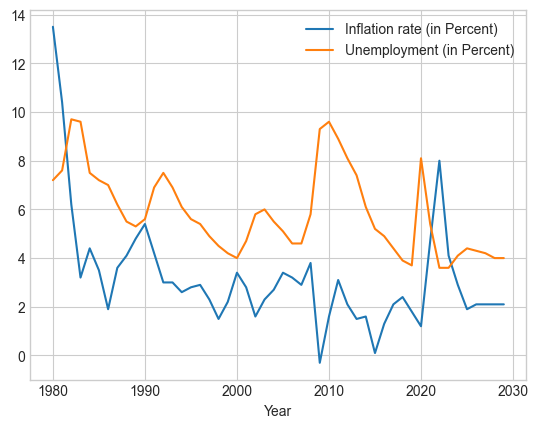

In [22]:
# Plot inflation and unemployment rates over time

# used seaborn-v0_8-whitegrid which is what I have
plt.style.use('seaborn-v0_8-whitegrid')
df_GDP.plot.line(x='Year', y=['Inflation rate (in Percent)', 'Unemployment (in Percent)'])


### Descriptive Statistics - Measures of Center

In [23]:
# Import required libraries
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [24]:
# Load mtcars dataset and clean column names
mtcars = pd.read_csv("data/mtcars.csv")
mtcars = mtcars.rename(columns={"Unnamed: 0": "model"})
mtcars.index = mtcars.model
del mtcars["model"]

# Display the first few rows
mtcars.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
model,,,,,,,,,,,
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [25]:
# Calculate the mean of each column
mtcars.mean()

mpg      20.090625
cyl       6.187500
disp    230.721875
hp      146.687500
drat      3.596563
wt        3.217250
qsec     17.848750
vs        0.437500
am        0.406250
gear      3.687500
carb      2.812500
dtype: float64

In [26]:
# Calculate the mean of each row
mtcars.mean(axis=1)

model
Mazda RX4              29.907273
Mazda RX4 Wag          29.981364
Datsun 710             23.598182
Hornet 4 Drive         38.739545
Hornet Sportabout      53.664545
Valiant                35.049091
Duster 360             59.720000
Merc 240D              24.634545
Merc 230               27.233636
Merc 280               31.860000
Merc 280C              31.787273
Merc 450SE             46.430909
Merc 450SL             46.500000
Merc 450SLC            46.350000
Cadillac Fleetwood     66.232727
Lincoln Continental    66.058545
Chrysler Imperial      65.972273
Fiat 128               19.440909
Honda Civic            17.742273
Toyota Corolla         18.814091
Toyota Corona          24.888636
Dodge Challenger       47.240909
AMC Javelin            46.007727
Camaro Z28             58.752727
Pontiac Firebird       57.379545
Fiat X1-9              18.928636
Porsche 914-2          24.779091
Lotus Europa           24.880273
Ford Pantera L         60.971818
Ferrari Dino           34.508182
Mase

### Descriptive Statistics - Median Calculation

In [27]:
# Calculate the median of each column
mtcars.median()

mpg      19.200
cyl       6.000
disp    196.300
hp      123.000
drat      3.695
wt        3.325
qsec     17.710
vs        0.000
am        0.000
gear      4.000
carb      2.000
dtype: float64

In [28]:
# Calculate the median of each row
mtcars.median(axis=1)

model
Mazda RX4              4.000
Mazda RX4 Wag          4.000
Datsun 710             4.000
Hornet 4 Drive         3.215
Hornet Sportabout      3.440
Valiant                3.460
Duster 360             4.000
Merc 240D              4.000
Merc 230               4.000
Merc 280               4.000
Merc 280C              4.000
Merc 450SE             4.070
Merc 450SL             3.730
Merc 450SLC            3.780
Cadillac Fleetwood     5.250
Lincoln Continental    5.424
Chrysler Imperial      5.345
Fiat 128               4.000
Honda Civic            4.000
Toyota Corolla         4.000
Toyota Corona          3.700
Dodge Challenger       3.520
AMC Javelin            3.435
Camaro Z28             4.000
Pontiac Firebird       3.845
Fiat X1-9              4.000
Porsche 914-2          4.430
Lotus Europa           4.000
Ford Pantera L         5.000
Ferrari Dino           6.000
Maserati Bora          8.000
Volvo 142E             4.000
dtype: float64

# Comparing Mean and Median in Symmetric Distributions

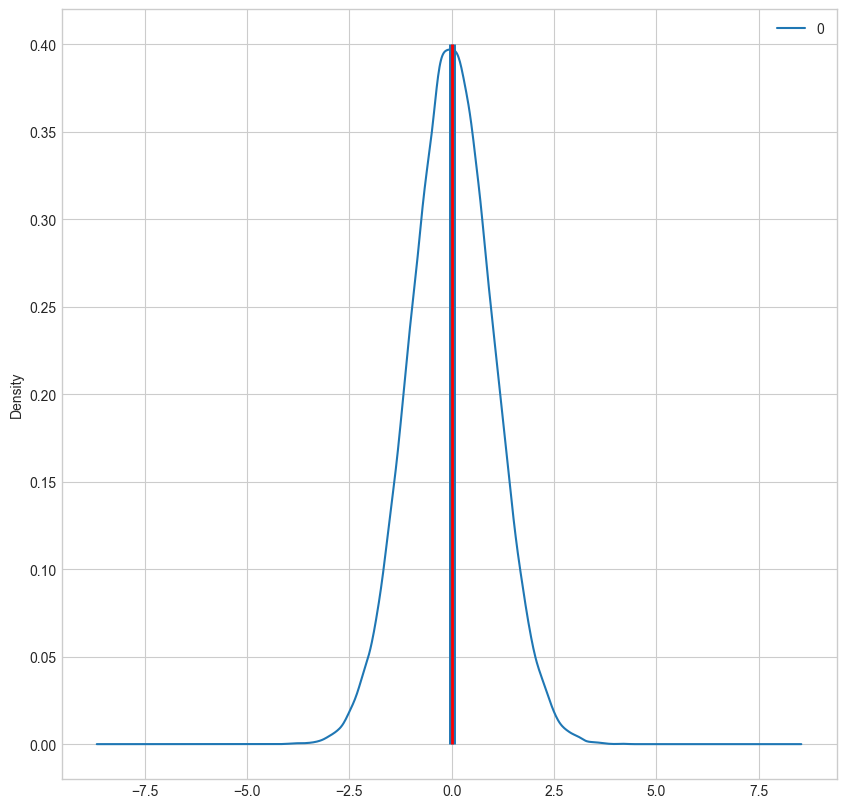

In [29]:
# Generate random normal data
norm_data = pd.DataFrame(np.random.normal(size=100000))

# Plot density of the data
norm_data.plot(kind="density", figsize=(10, 10))

# Add vertical lines for mean and median
plt.vlines(norm_data.mean(), ymin=0, ymax=0.4, linewidth=5.0)  # Black line at mean
plt.vlines(norm_data.median(), ymin=0, ymax=0.4, linewidth=2.0, color="red")  # Red line at median

### Exploring Skewed Distributions

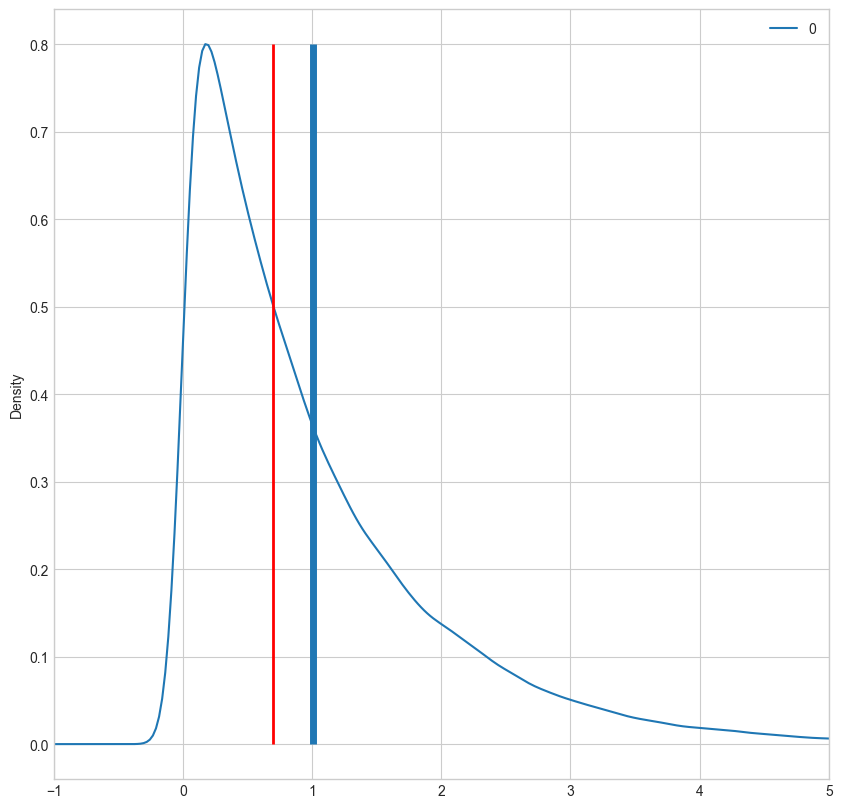

In [30]:
# Generate random exponential data
skewed_data = pd.DataFrame(np.random.exponential(size=100000))

# Plot density of the data
skewed_data.plot(kind="density", figsize=(10, 10), xlim=(-1, 5))

# Add vertical lines for mean and median
plt.vlines(skewed_data.mean(), ymin=0, ymax=0.8, linewidth=5.0)  # Black line at mean
plt.vlines(skewed_data.median(), ymin=0, ymax=0.8, linewidth=2.0, color="red")  # Red line at median


### The Impact of Outliers on Mean and Median

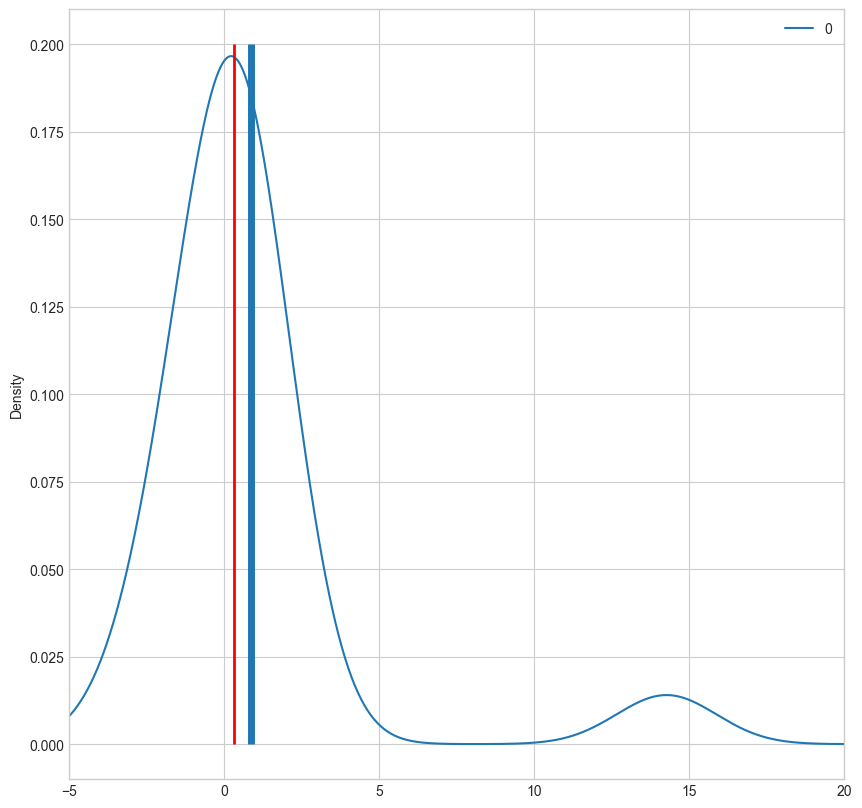

In [31]:
# Generate normal data and add outliers
norm_data = np.random.normal(size=50)
outliers = np.random.normal(15, size=3)
combined_data = pd.DataFrame(np.concatenate((norm_data, outliers), axis=0))

# Plot combined data density
combined_data.plot(kind="density", figsize=(10, 10), xlim=(-5, 20))

# Add vertical lines for mean and median
plt.vlines(combined_data.mean(), ymin=0, ymax=0.2, linewidth=5.0)  # Black line at mean
plt.vlines(combined_data.median(), ymin=0, ymax=0.2, linewidth=2.0, color="red")  # Red line at median

In [32]:
# Find the mode of the dataset
mtcars.mode()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,10.4,8.0,275.8,110.0,3.07,3.44,17.02,0.0,0.0,3.0,2.0
1,15.2,NaN,NaN,175.0,3.92,NaN,18.90,NaN,NaN,NaN,4.0
2,19.2,NaN,NaN,180.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,21.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,22.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,30.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Measures of Spread - Range and Percentiles

In [33]:
# Calculate the range of mpg values
max(mtcars["mpg"]) - min(mtcars["mpg"])

23.5

In [34]:
# Calculate the five-number summary
five_num = [
    mtcars["mpg"].quantile(0),
    mtcars["mpg"].quantile(0.25),
    mtcars["mpg"].quantile(0.50),
    mtcars["mpg"].quantile(0.75),
    mtcars["mpg"].quantile(1)
]
five_num

[np.float64(10.4),
 np.float64(15.425),
 np.float64(19.2),
 np.float64(22.8),
 np.float64(33.9)]

### Descriptive Statistics - Five-Number Summary and IQR

In [35]:
# Generate a five-number summary using describe()
mtcars["mpg"].describe()

count    32.000000
mean     20.090625
std       6.026948
min      10.400000
25%      15.425000
50%      19.200000
75%      22.800000
max      33.900000
Name: mpg, dtype: float64

In [36]:
# Calculate IQR as the difference between the third and first quartiles
mtcars["mpg"].quantile(0.75) - mtcars["mpg"].quantile(0.25)

np.float64(7.375)

<Axes: >

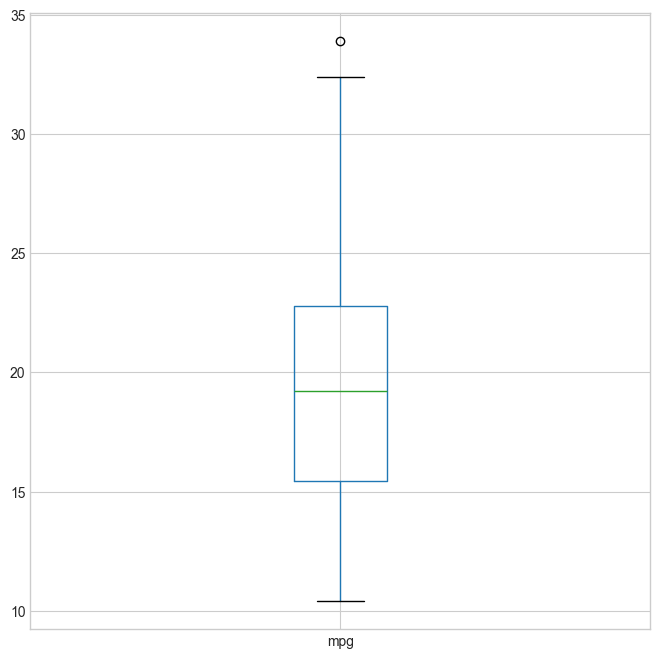

In [37]:
# Create a boxplot for the mpg column
mtcars.boxplot(column="mpg", return_type="axes", figsize=(8, 8))

### Variance and Standard Deviation

In [38]:
# Calculate variance of the mpg column
mtcars["mpg"].var()

np.float64(36.32410282258064)

In [39]:
# Calculate standard deviation of the mpg column
mtcars["mpg"].std()

np.float64(6.026948052089104)

### Median Absolute Deviation (MAD)

In [40]:
# Calculate median absolute deviation
abs_median_devs = abs(mtcars["mpg"] - mtcars["mpg"].median())
mad = abs_median_devs.median() * 1.4826  # Scaling factor for normal data
mad

np.float64(5.411490000000001)

### Skewness and Kurtosis

In [41]:
# Check skewness of the mpg column
mtcars["mpg"].skew()

np.float64(0.6723771376290805)

In [42]:
# Check kurtosis of the mpg column
mtcars["mpg"].kurt()

np.float64(-0.0220062914240855)

### Exploring Skewness and Kurtosis with Dummy Data

In [45]:
# Create dummy datasets with different distributions
norm_data = np.random.normal(size=100000)
skewed_data = np.concatenate((np.random.normal(size=35000)+2, np.random.exponential(size=65000)), axis=0)
uniform_data = np.random.uniform(0, 2, size=100000)
peaked_data = np.concatenate((np.random.exponential(size=50000), -np.random.exponential(size=50000)), axis=0)

# Combine data into a DataFrame
data_df = pd.DataFrame({
    "norm": norm_data,
    "skewed": skewed_data,
    "uniform": uniform_data,
    "peaked": peaked_data
})

<Axes: ylabel='Density'>

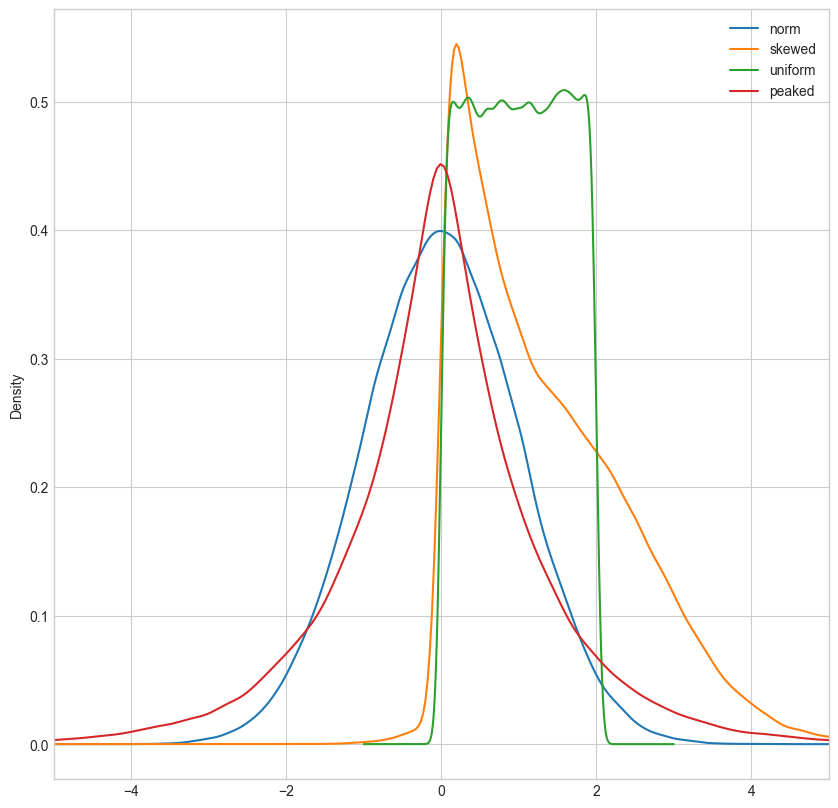

In [46]:
# Plot density of the distributions
data_df.plot(kind="density", figsize=(10, 10), xlim=(-5, 5))

In [47]:
# Check skewness of all distributions
data_df.skew()

norm       0.011362
skewed     1.037125
uniform   -0.007190
peaked    -0.008270
dtype: float64

In [48]:
# Check kurtosis of all distributions
data_df.kurt()

norm      -0.030864
skewed     1.574120
uniform   -1.207294
peaked     2.992590
dtype: float64